# Stage 2 — Linear baseline (ridge regression)

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interpn
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

DATA = "/Users/ewellmeyer/Documents/research/scripts/cloud_feedbacks/data"

# Common 2.5-degree grid (matches cfmip_cre.nc and ceres_cre.nc)
COMMON_LAT = np.arange(-88.75, 90.0,  2.5)   # 72 points
COMMON_LON = np.arange(  0.0, 360.0,  2.5)   # 144 points
N_LAT, N_LON = len(COMMON_LAT), len(COMMON_LON)

_glon, _glat = np.meshgrid(COMMON_LON, COMMON_LAT)
_pts = np.stack([_glat.ravel(), _glon.ravel()], axis=-1)

def to_common_grid(arr, src_lat, src_lon):
    """Bilinear regrid (n, lat, lon) or (lat, lon) to the common 2.5° grid."""
    scalar = arr.ndim == 2
    if scalar:
        arr = arr[None]
    out = np.empty((arr.shape[0], N_LAT, N_LON), dtype=np.float32)
    for i in range(arr.shape[0]):
        out[i] = interpn(
            (src_lat, src_lon), arr[i], _pts,
            method="linear", bounds_error=False, fill_value=None
        ).reshape(N_LAT, N_LON)
    return out[0] if scalar else out

def load_and_regrid(cre_path, fb_path, member_dim):
    """Load CRE and feedback, regrid CRE to common grid, return flat feature matrix."""
    cre = xr.open_dataset(cre_path)["cre"]
    fb  = xr.open_dataset(fb_path)["delta_net_cre"].values
    src_lat = cre.latitude.values
    src_lon = cre.longitude.values
    sw = cre.sel(channel="sw_cre").values
    lw = cre.sel(channel="lw_cre").values
    sw_c = to_common_grid(sw, src_lat, src_lon)
    lw_c = to_common_grid(lw, src_lat, src_lon)
    X = np.concatenate([sw_c.reshape(len(fb), -1),
                        lw_c.reshape(len(fb), -1)], axis=1)
    return X, fb

print("Loading GA8...")
X_ga8, y_ga8 = load_and_regrid(f"{DATA}/hadgem_ga8_cre.nc", f"{DATA}/hadgem_ga8_fb.nc", "realization")
print("Loading GA9...")
X_ga9, y_ga9 = load_and_regrid(f"{DATA}/hadgem_ga9_cre.nc", f"{DATA}/hadgem_ga9_fb.nc", "realization")
print(f"GA8: {X_ga8.shape[0]} members, {X_ga8.shape[1]} features")
print(f"GA9: {X_ga9.shape[0]} members")

Loading GA8...
Loading GA9...
GA8: 503 members, 20736 features
GA9: 503 members


## Ridge regression on GA8

Train on all of GA8 with 10-fold cross-validation to select the regularisation strength (alpha) and estimate in-sample generalisation. The scaler is fit on each training fold independently to avoid leakage. RidgeCV searches over a log-spaced alpha grid and selects via generalised cross-validation internally; we wrap it in an outer KFold to get honest held-out predictions across all members.

In [2]:
ALPHAS = np.logspace(-1, 8, 60)
N_FOLDS = 10

kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
y_ga8_cv = np.empty_like(y_ga8)
alphas_chosen = []

for train_idx, val_idx in kf.split(X_ga8):
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_ga8[train_idx])
    X_val = scaler.transform(X_ga8[val_idx])

    ridge = RidgeCV(alphas=ALPHAS, fit_intercept=True)
    ridge.fit(X_tr, y_ga8[train_idx])
    y_ga8_cv[val_idx] = ridge.predict(X_val)
    alphas_chosen.append(ridge.alpha_)

r2_cv   = r2_score(y_ga8, y_ga8_cv)
rmse_cv = np.sqrt(mean_squared_error(y_ga8, y_ga8_cv))
print(f"GA8 10-fold CV   R²={r2_cv:.3f}  RMSE={rmse_cv:.3f} W/m²")
print(f"Alpha range selected: {min(alphas_chosen):.1e} – {max(alphas_chosen):.1e}")

# Fit a single model on all GA8 data for use in out-of-sample evaluation
scaler_ga8 = StandardScaler().fit(X_ga8)
X_ga8_s = scaler_ga8.transform(X_ga8)
ridge_ga8 = RidgeCV(alphas=ALPHAS, fit_intercept=True)
ridge_ga8.fit(X_ga8_s, y_ga8)
print(f"\nFinal model alpha: {ridge_ga8.alpha_:.1e}")

GA8 10-fold CV   R²=0.869  RMSE=0.208 W/m²
Alpha range selected: 1.6e+02 – 3.2e+02

Final model alpha: 3.2e+02


## Predicted vs actual — GA8 cross-validation

Each point is one ensemble member, predicted from a fold it was not trained on. The 1:1 line is perfect prediction. Spread around it is the irreducible error from the linear model given this feature set.

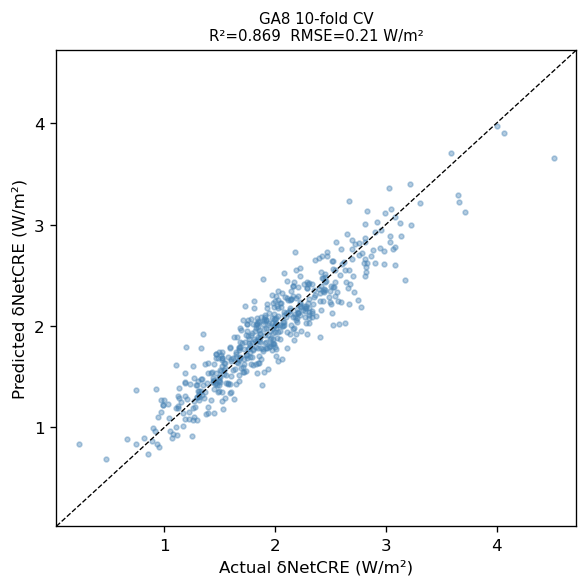

In [3]:
def scatter_pred(ax, y_true, y_pred, label, color, marker="o", alpha=0.4, s=8):
    ax.scatter(y_true, y_pred, c=color, alpha=alpha, s=s, marker=marker, label=label)
    lo = min(y_true.min(), y_pred.min()) - 0.2
    hi = max(y_true.max(), y_pred.max()) + 0.2
    ax.plot([lo, hi], [lo, hi], "k--", linewidth=0.8)
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    ax.set_title(f"{label}\nR²={r2:.3f}  RMSE={rmse:.2f} W/m²", fontsize=9)
    ax.set_xlabel("Actual δNetCRE (W/m²)")
    ax.set_ylabel("Predicted δNetCRE (W/m²)")
    return r2, rmse

fig, ax = plt.subplots(figsize=(5, 5))
scatter_pred(ax, y_ga8, y_ga8_cv, "GA8 10-fold CV", "steelblue")
plt.tight_layout()
plt.show()

## Out-of-sample evaluation: GA9 and CESM2

GA8-trained model applied to datasets it has never seen. GA9 tests generalisation across HadGEM physics generations (same model family, different parameter perturbations). CESM2 tests generalisation across model structure. 

For CESM2 the SW channel is a proxy (rsdt − SW_CRE) not directly comparable to the GA8 SW CRE the scaler was fit on — the standardised CESM2 SW features will be severely out of distribution. To isolate this, we evaluate CESM2 twice: once with both channels (as-is) and once with only the LW channel, to see how much the broken SW channel contaminates the prediction.

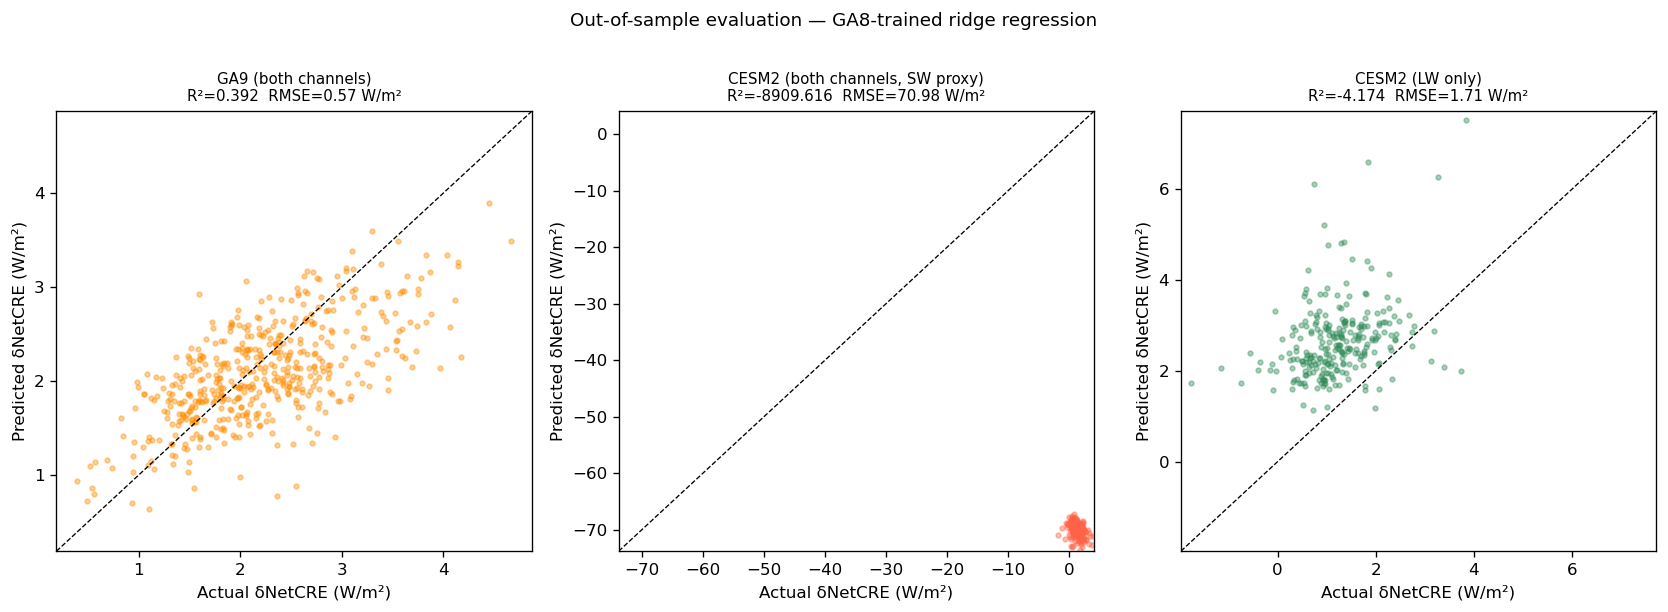

In [4]:
## Load CESM2
c2_cre = xr.open_dataset(f"{DATA}/cesm2_cre.nc")["cre"]
c2_fb  = xr.open_dataset(f"{DATA}/cesm2_fb.nc")["delta_net_cre"].values
c2_lat = c2_cre.latitude.values
c2_lon = c2_cre.longitude.values

c2_sw_c = to_common_grid(c2_cre.sel(channel="sw_cre").values, c2_lat, c2_lon)
c2_lw_c = to_common_grid(c2_cre.sel(channel="lw_cre").values, c2_lat, c2_lon)

X_c2_both = np.concatenate([c2_sw_c.reshape(len(c2_fb), -1),
                             c2_lw_c.reshape(len(c2_fb), -1)], axis=1)
X_c2_lw   = c2_lw_c.reshape(len(c2_fb), -1)

# GA8 LW-only scaler and model for fair CESM2 comparison
n_sw_feats = N_LAT * N_LON
scaler_ga8_lw = StandardScaler().fit(X_ga8[:, n_sw_feats:])
X_ga8_lw_s    = scaler_ga8_lw.transform(X_ga8[:, n_sw_feats:])
ridge_ga8_lw  = RidgeCV(alphas=ALPHAS, fit_intercept=True).fit(X_ga8_lw_s, y_ga8)

## Evaluate
results = {}

# GA9 (both channels)
X_ga9_s = scaler_ga8.transform(X_ga9)
y_ga9_pred = ridge_ga8.predict(X_ga9_s)
results["GA9 (both channels)"] = (y_ga9, y_ga9_pred, "darkorange")

# CESM2 both channels (SW proxy — expected to be poor)
X_c2_both_s = scaler_ga8.transform(X_c2_both)
y_c2_both_pred = ridge_ga8.predict(X_c2_both_s)
results["CESM2 (both channels, SW proxy)"] = (c2_fb, y_c2_both_pred, "tomato")

# CESM2 LW only (fair comparison)
X_c2_lw_s = scaler_ga8_lw.transform(X_c2_lw)
y_c2_lw_pred = ridge_ga8_lw.predict(X_c2_lw_s)
results["CESM2 (LW only)"] = (c2_fb, y_c2_lw_pred, "seagreen")

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, (label, (y_true, y_pred, color)) in zip(axes, results.items()):
    scatter_pred(ax, y_true, y_pred, label, color)
plt.suptitle("Out-of-sample evaluation — GA8-trained ridge regression", fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

## CFMIP structural generalisation test

10 models, one prediction each. Too few for a meaningful R² but the scatter shows whether the model gets the sign and rough ordering right across structurally diverse models. The two PPE parent models (HadGEM3-GC31-LL and CESM2) are highlighted — they should be the easiest to predict since the training data came from their respective model families.

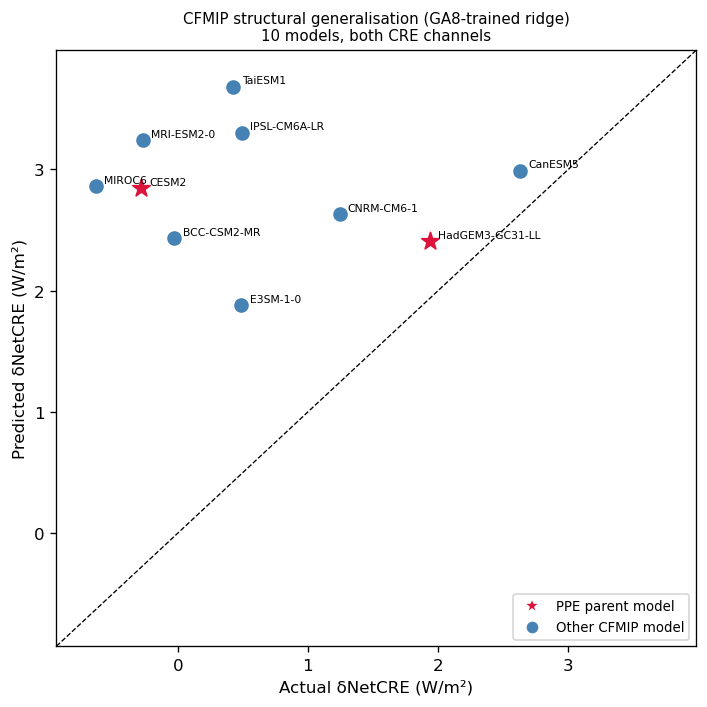

In [5]:
cfmip_cre = xr.open_dataset(f"{DATA}/cfmip_cre.nc")["cre"]
cfmip_fb  = xr.open_dataset(f"{DATA}/cfmip_fb.nc")["delta_net_cre"]
cfmip_lat = cfmip_cre.latitude.values
cfmip_lon = cfmip_cre.longitude.values
models    = [str(m) for m in cfmip_cre.model.values]

# CFMIP is already on the common 2.5° grid — no regridding needed
X_cfmip = np.concatenate([
    cfmip_cre.sel(channel="sw_cre").values.reshape(len(models), -1),
    cfmip_cre.sel(channel="lw_cre").values.reshape(len(models), -1),
], axis=1)
y_cfmip = cfmip_fb.values

X_cfmip_s   = scaler_ga8.transform(X_cfmip)
y_cfmip_pred = ridge_ga8.predict(X_cfmip_s)

PARENT_MODELS = {"HadGEM3-GC31-LL", "CESM2"}

fig, ax = plt.subplots(figsize=(6, 6))
for i, model in enumerate(models):
    color  = "crimson"  if model in PARENT_MODELS else "steelblue"
    marker = "*"        if model in PARENT_MODELS else "o"
    size   = 120        if model in PARENT_MODELS else 60
    ax.scatter(y_cfmip[i], y_cfmip_pred[i], c=color, marker=marker, s=size, zorder=3)
    ax.annotate(model, (y_cfmip[i], y_cfmip_pred[i]),
                fontsize=6.5, textcoords="offset points", xytext=(5, 2))

lo = min(y_cfmip.min(), y_cfmip_pred.min()) - 0.3
hi = max(y_cfmip.max(), y_cfmip_pred.max()) + 0.3
ax.plot([lo, hi], [lo, hi], "k--", linewidth=0.8)
ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
ax.set_xlabel("Actual δNetCRE (W/m²)")
ax.set_ylabel("Predicted δNetCRE (W/m²)")

from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker="*", color="w", markerfacecolor="crimson",  markersize=10, label="PPE parent model"),
                   Line2D([0], [0], marker="o", color="w", markerfacecolor="steelblue", markersize=8,  label="Other CFMIP model")]
ax.legend(handles=legend_elements, fontsize=8)
ax.set_title("CFMIP structural generalisation (GA8-trained ridge)\n10 models, both CRE channels", fontsize=9)
plt.tight_layout()
plt.show()

## Summary metrics and CERES prediction

Collect all R²/RMSE numbers in one place, then apply the GA8-trained model to CERES to get a preliminary observational constraint. This is just a linear baseline number — treat it as a reference point, not a final result.

In [6]:
print("=" * 55)
print(f"{'Dataset':<35} {'R²':>6}  {'RMSE':>8}")
print("-" * 55)

rows = [
    ("GA8 10-fold CV",              y_ga8,  y_ga8_cv),
    ("GA9 (out-of-sample)",         y_ga9,  y_ga9_pred),
    ("CESM2 both channels (proxy)", c2_fb,  y_c2_both_pred),
    ("CESM2 LW only",               c2_fb,  y_c2_lw_pred),
]
for label, y_true, y_pred in rows:
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{label:<35} {r2:>6.3f}  {rmse:>6.3f} W/m²")

print("=" * 55)

# CERES prediction
ceres_cre = xr.open_dataset(f"{DATA}/ceres_cre.nc")["cre"]
ceres_sw  = ceres_cre.sel(channel="sw_cre").values  # already on common grid
ceres_lw  = ceres_cre.sel(channel="lw_cre").values

X_ceres = np.concatenate([ceres_sw.ravel()[None], ceres_lw.ravel()[None]], axis=1)
X_ceres_s = scaler_ga8.transform(X_ceres)
ceres_pred = ridge_ga8.predict(X_ceres_s)[0]

print(f"\nCERES observational constraint (linear baseline):")
print(f"  Predicted δNetCRE = {ceres_pred:.2f} W/m²")
print(f"  As feedback parameter = {ceres_pred/4:.3f} W/m²/K")

Dataset                                 R²      RMSE
-------------------------------------------------------
GA8 10-fold CV                       0.869   0.208 W/m²
GA9 (out-of-sample)                  0.392   0.575 W/m²
CESM2 both channels (proxy)         -8909.616  70.981 W/m²
CESM2 LW only                       -4.174   1.710 W/m²

CERES observational constraint (linear baseline):
  Predicted δNetCRE = 4.11 W/m²
  As feedback parameter = 1.026 W/m²/K
